In [88]:
"""
@
Auteurs:        Jeffrey Jason Boekstaaf, Tim Paulus van Croimvort en Haydar Eryörük
Studentnummers: 500460365, 500916516 en 500910901
Datum:          20-03-2026
Vak:            Beroepsproject 3.4
Opleiding:      Toegepaste Wiskunde & Data Science
School:         Hogeschool van Amsterdam
"""

# Importeeer de benodigde packages.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, RocCurveDisplay,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score



data_train = pd.read_csv("data_train.csv")

In [89]:
# numerieke kolommen en categorische kolommen waarbij het referentie niveau gedropt wordt.
numcols = ['Call Failure','Subscription Length','Seconds of Use','Frequency of use','Frequency of SMS']
faccols = ['Age Group','Complaints']
droplevels = [1,0]

# columntransformer voor de datapreperatie fase.
dataprep = ColumnTransformer([
    ('numeriek', StandardScaler(), numcols),
    ('categorisch', OneHotEncoder(drop = droplevels, sparse_output=False), faccols),
], remainder = 'drop', verbose_feature_names_out = False)

dataprep.set_output(transform='pandas')
dataprep

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeriek', ...), ('categorisch', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

We gebruiken een standardscaler voor de numerieke kollomen en een onehotencoder voor de categorische variabelen, waarbij het referentieniveau gedropt wordt. Dit stoppen wij in een columntransformer waardoor de kollomen getransformeerd worden.

Hieronder wordt de beslisboom gefit met de hyperparameters max_depth = 3 (de boom heeft een maximale diepte van 3),min_samples_leaf = 1 (elke boom heeft minstens 1 sample) en een random_state = 1987 voor reproduceerbaarheid van de resultaten. Onderaan wordt de accuracy gegeven van het model op 2 decimalen.

In [90]:
# De beslisboom wordt gefit.
X_train = data_train.drop(columns = ['Churn'])
y_train = data_train['Churn']

model = Pipeline([('preprocessing', dataprep),
                  ('model', DecisionTreeClassifier(max_depth = 4,
                                                   min_samples_leaf=1,random_state = 1987))])
# de hyperparameters zijn zo gekozen,omdat het aanbevolen wordt door de userguide van sklearn.
model.fit(X_train, y_train)
y_pred =model.predict(X_train)
print(f'accuracy model: {accuracy_score(y_train,y_pred):.2f}')



accuracy model: 0.91


In onderstaande cel wordt een visualisatie van de boom gemaakt met een max_depth van 2,zodat de child-nodes zichtbaar zijn.

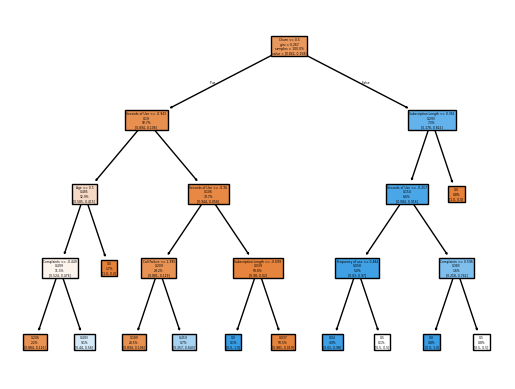

In [91]:
# In deze cel wordt een plot gemaakt van de boom.
# De diepte van de plot is 1 zodat de waarden duidelijk zichtbaar.

plot_tree(model.named_steps['model'],
            feature_names = data_train.columns,
            filled = True,
            proportion=True,
            label = 'root')
plt.show()


In de visualisatie is de boom te zien van de decisiontree. Per leaf is te zien hoeveel procent van de sample het bevat,de voorwaarde waarop gesplitst wordt. De kansen op de uitkomsten True en False en de gini index score.uiteindelijk eindigt de boom met [1,0] wat betekent dat er een voorspelling is voor churn.

In [92]:
# De waardes van alpha worden gehaald uit de volledige boom.

alphas = DecisionTreeClassifier(max_depth = 4,min_samples_leaf = 1,random_state = 1987).fit(X_train, y_train).cost_complexity_pruning_path(X_train, y_train)
alphas = np.unique(alphas['ccp_alphas'])
alphas

array([0.        , 0.00045195, 0.00096411, 0.00158714, 0.00378022,
       0.00670189, 0.01132183, 0.02864959, 0.06952746])

In [93]:
# Hieronder wordt een gridsearch uitgevoerd om de beste waarde van alpha te bepalen.
# Dit doen wij aan de hand van de roc_auc score.

gridsearch = GridSearchCV(
    model,
    param_grid = {'model__ccp_alpha' : alphas
                  },
    scoring = 'accuracy',
    n_jobs=-2).fit(X_train, y_train)


best_alpha = gridsearch.best_params_['model__ccp_alpha']
best_score = gridsearch.best_score_

print(f'Best gevonden alpha: {best_alpha:.4e}, accuracy = {best_score:.2f}')
gridsearch.best_estimator_

Best gevonden alpha: 3.7802e-03, accuracy = 0.90


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeriek', ...), ('categorisch', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

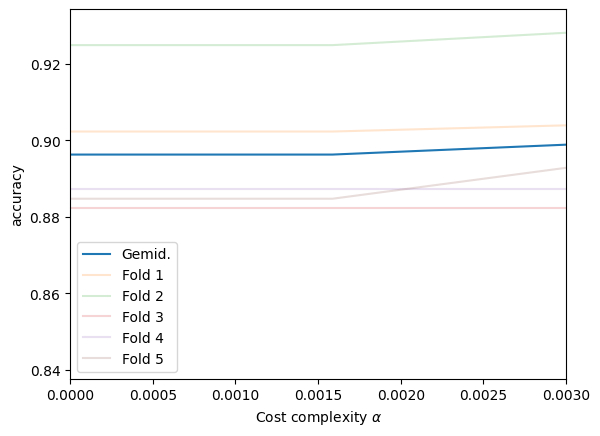

In [94]:
# In deze cel wordt een plot gemaakt waarbij de alpha uitgezet wordt tegen de auc-score.

sns.lineplot(gridsearch.cv_results_, x = 'param_model__ccp_alpha', y = 'mean_test_score', label = 'Gemid.')
for i in range(5):
    sns.lineplot(gridsearch.cv_results_, 
                 x = 'param_model__ccp_alpha', 
                 y = f'split{i}_test_score', 
                 alpha = 0.2, 
                 label = f'Fold {i+1}')
plt.plot(best_alpha, best_score, 'ro')
plt.xlim(0, 0.003)
plt.xlabel('Cost complexity $\\alpha$')
plt.ylabel('accuracy')
plt.show()

In de visualisatie is te zien dat de accuracy niet/nauwelijks veranderd en ook denkt dat het geen alpha nodig heeft.
In de plot is te zien dat de accuracy bijna niet veranderd,omdat het model denkt dat er geen alpha nodig is voor de beslisboom.

In onderstaande cel worden 3 plots gemaakt.
- Een plot van de verdeling van de voorspelde kansen voor Churn.
- Een metric plot die de waardes van de accuracy, precision, recall en F1-score.
- Een ROC-curve die laat de AUC-score laat zien van het model.

c:\Users\Eigenaar\python Toegepaste Wiskunde\envs\BP3.4\Lib\site-packages\sklearn\utils\_plotting.py:440: FutureWarning: y_pred was deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(


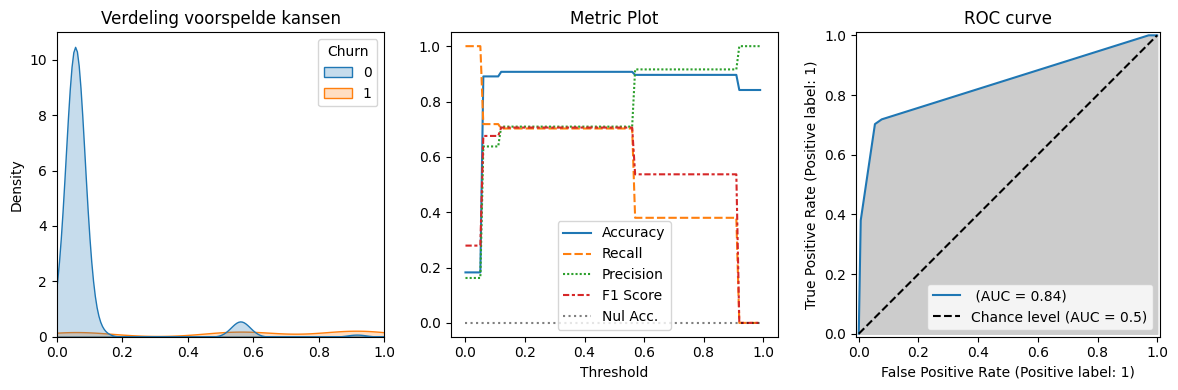

accuracy model: 0.91


In [95]:
# In deze  cel worden 3  plots gemaakt de verdeling voorspelde kansen, een metric plot en een roc curve.
y_pred = gridsearch.predict_proba(X_train)

# Functie die een classificatie report omzet in rijen van een dataframe.
def make_row(cr):
    return {
        'Accuracy':  cr['accuracy'],
        'Recall':    cr['1']['recall'],
        'Precision': cr['1']['precision'],
        'F1 Score':  cr['1']['f1-score']
    }

thresholds = np.arange(0, 1, 0.01)
plot_data = pd.DataFrame([
    make_row(classification_report(
        y_train, 
        y_pred[:,1] > t, 
        zero_division=True, 
        output_dict=True)) for t in thresholds])
plot_data.index = thresholds

plt.figure(figsize=(12,4), layout='tight')

# Plot 1: Verdeling van de voorspelde kansen.
plt.subplot(1,3,1)
sns.kdeplot(data_train, x = y_pred[:,1], hue = 'Churn',fill = True)
plt.xlim(0,1)
plt.title('Verdeling voorspelde kansen')

# Plot 2: Een metric plot.
nul_acc = 0
plt.subplot(1,3,2)
sns.lineplot(plot_data)
plt.plot([0,1], [nul_acc, nul_acc], 'k:', alpha = 0.5, label = 'Nul Acc.')
plt.xlabel('Threshold')
plt.legend()
plt.title('Metric Plot')


# Plot 3: Een ROC curve.
ax = plt.subplot(1,3,3)
roc = RocCurveDisplay.from_predictions(
    y_train, 
    y_pred=y_pred[:,1], 
    name = '', 
    plot_chance_level = True,
    ax=ax)
plt.fill_between(roc.fpr, roc.tpr, color = '0.8')
plt.title('ROC curve')
plt.show()
print(f'accuracy model: {accuracy_score(y_train,gridsearch.predict(X_train)):.2f}')



In de eerste plot is te zien dat de density functie van churn = 0 hogere waardes voor density aantikt vergeleken met die van churn = 1. Dit komt omdat de data veel meer klanten heeft die hun abbonement niet opzeggen vergeleken met de klanten die het wel doen.
In de tweede plot zijn de waardes van verschillende metrics te zien. Opvallend is dat als de precision toeneemt dan neemt de recall af. De F1-score zit tussen de recall en precision in.
In de derde plot is de roc curve te zien van het model met een AUC van 0.89.

In onderstaande cel wordt het volgende uitgevoerd:
- Er wordt een confusionmatrix gemaakt van churn op basis van de traindata
- Een dataframe die de accuracy,recall,precision en F1-score van het model laat zien

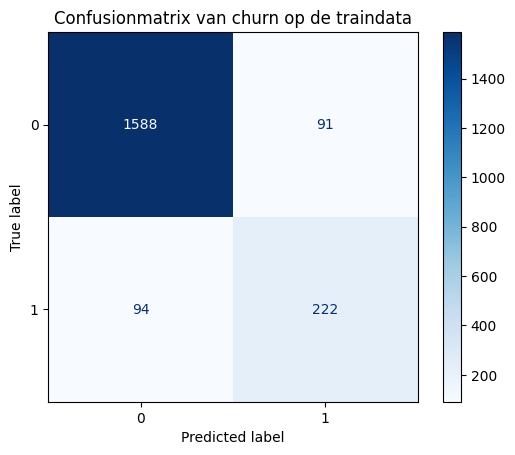

,Name,Value
0,Accuracy,0.91
1,Recall,0.70
2,Precision,0.71
3,F1-score,0.71


In [96]:
# Confusionmatrix van de voorspelling.

y_pred = gridsearch.predict(X_train)
ConfusionMatrixDisplay.from_predictions(y_train,y_pred, cmap = 'Blues')
plt.title('Confusionmatrix van churn op de traindata')
plt.show()

# Hier worden de accuracy, f1, precision en recall scores berekend en gegeven.
acc = round(accuracy_score(y_train, y_pred ), 2)
rec = round(recall_score(y_train, y_pred ), 2)
pre = round(precision_score(y_train, y_pred ), 2)
fsco = round(f1_score(y_train, y_pred ), 2)

table = {"Name": ["Accuracy", "Recall", "Precision", "F1-score"],
        "Value": [acc, rec, pre, fsco]}
df = pd.DataFrame(table)
df


In de confusion matrix is te zien dat er over het algemeen goed voorspelt wordt die te zien is aan de labels (0,0) en (1,1).- 
- 1592 klanten die niet opzeggen worden niet gebeld en 120 klanten die wel opzeggen worden wel gebeld.
- 223 klanten die wel besluiten op te zeggen worden gebeld.
- 93 klanten die wel besluiten op te zeggen worden niet gebeld.
- 87 klanten die niet besluiten op te zeggen worden gebeld.

In de dataframe zijn de waarden per prestatie maat te zien:
- De accuracy van het model is 91%.
- De recall van het model is 70%.
- De precision van het model is 72%.
- De F1-score van het model is 71%.